# Predicting Stock Returns with Deep Learning

This project walks you through the end-to-end data science lifecycle of developing a predictive model for stock price movements with Yahoo Finance's APIs and a machine learning algorithm called Long Short-Term Memory (LSTM).

## Install Packages

In [ ]:
%pip -q install -U

In [1]:
#@title Load Libraries

# time
from datetime import datetime, timedelta
import pytz

# data manipulation
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

# financial data
import yfinance as yf

# deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# sentiment
#from stocksent import Sentiment

In [2]:
#@title Set Device

if torch.cuda.is_available():
    device_string = "cuda"
    print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device_string = "mps"
    print("MPS is available. Using Apple Silicon GPU.")
else:
    device_string = "cpu"
    print("CUDA and MPS are not available. Using CPU.")

device = torch.device(device_string)

MPS is available. Using Apple Silicon GPU.


## Configuration

Here, configurations for the NN are predefined. for choosing interval and period, consider the following (according to Holstein et al.):


| Estimation Window | Frequency | Prediction Horizon |
| ----------------- | --------- | ------------------ |
| 1 to 60 months    | daily     | a day              |
| 12, 36, 60 months | monthly   | a month            |
| 10 years          | quarterly | a quarter          |

In [ ]:
# configuration dictionary
config = {
    "yfinance": {
        "symbol": "AAPL", # choose ticker to be analysed. here, we take a total return index on S&P 500
        "volatility": "^VIX", # 30-day forward projection of volatility
        "interest_rates": "^TNX", # CBOE Interest Rate 10 Year T No
        "market": "^SP500TR", # specify a market index
        "component": "Close", # Open, High, Low, Close, Volume
        "interval": "1d", # data frequency
        "period": "3y", # estimation window
    },
    "data": {
        "window_size": 20,
        "train_split_size": 0.80,
    },
    "plots": {
        "show_plots": True,
        "xticks_interval": 90,
        "color_actual": "#001f3f",
        "color_train": "#3D9970",
        "color_val": "#0074D9",
        "color_pred_train": "#3D9970",
        "color_pred_val": "#0074D9",
        "color_pred_test": "#FF4136",
    },
    "model": {
        "input_size": 3,
        "num_lstm_layers": 3,
        "lstm_size": 32,
        "dropout": 0.2,
    },
    "training": {
        "batch_size": 64,
        "num_epoch": 100,
        "learning_rate": 0.01,
        "scheduler_step_size": 40,
    }
}

In [ ]:
def download_data(symbol, period, interval, component):
    ticker = yf.Ticker(symbol)
    df = ticker.history(period=period, interval=interval)
    df = df[[component]]
    return df

def calculate_returns(df):
    returns = df.pct_change().dropna()
    returns.columns = [col + '_returns' for col in returns.columns]
    return returns

def join(*args):
    nomralized_dfs = []
    for df in args:
        df.index = df.index.strftime('%Y-%m-%d')
        nomralized_dfs.append(df)
    combined_df = pd.concat(nomralized_dfs, axis=1, join='inner')
    combined_df = combined_df.dropna()
    return combined_df

Number data points: 752 from 2022-09-06 to 2025-09-04


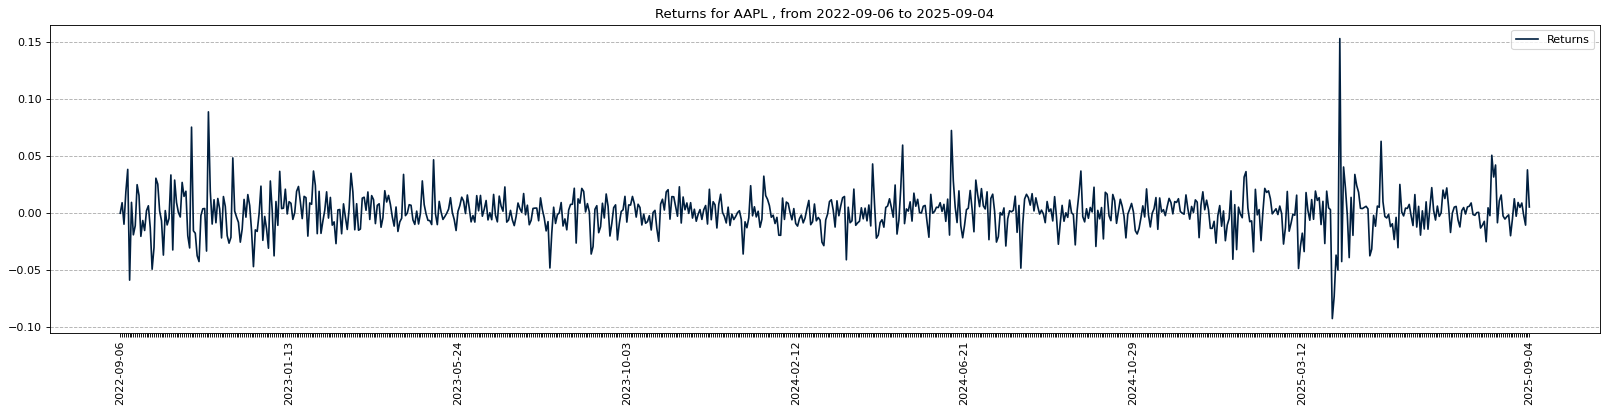

In [ ]:
#@title Data Preparation: Acquiring Financial Data

def download_data(config, plot=False):
    # define parameters
    period = config["yfinance"]["period"]
    interval = config["yfinance"]["interval"]
    price_type = config["yfinance"]["component"]

    # define tickers
    symbol = yf.Ticker(config["yfinance"]["symbol"])
    volatility = yf.Ticker(config["yfinance"]["volatility"])
    interest_rates = yf.Ticker(config["yfinance"]["interest_rates"])

    # fetch data
    prices = symbol.history(period=period, interval=interval)[[price_type]]
    vol = volatility.history(period=period, interval=interval)[[price_type]]
    interest = interest_rates.history(period=period, interval=interval)[[price_type]]

    # prepare for join
    prices.index = prices.index.strftime('%Y-%m-%d')
    prices = prices.rename(columns={price_type: 'Price'})
    vol.index = vol.index.strftime('%Y-%m-%d')
    vol = vol.rename(columns={price_type: 'Volatility'})
    interest.index = interest.index.strftime('%Y-%m-%d')
    interest = interest.rename(columns={price_type: 'Interest'})

    # join
    first = pd.merge(prices, vol, left_index=True, right_index=True, how='inner')
    all = pd.merge(first, interest, left_index=True, right_index=True, how='inner')

    # extract date, price, and volatility
    data_date = all.index.tolist()
    data_price = all['Price'].values
    data_vol = all['Volatility'].values
    data_interest = all['Interest'].values

    # calculate returns as percentage change on the 'Close' price
    data_return = np.diff(data_price) / data_price[:-1]
    # prepend a 0 to match the length of the original data, as the first return is undefined
    data_return = np.insert(data_return, 0, 0)

    # check if data is available
    num_data_points = len(data_date)
    display_date_range = "from " + data_date[0] + " to " + data_date[-1]
    print("Number data points:", num_data_points, display_date_range)

    if plot:
        fig = figure(figsize=(25, 5), dpi=80)
        fig.patch.set_facecolor((1.0, 1.0, 1.0))
        plt.plot(data_date, data_return, label="Returns", color=config["plots"]["color_actual"])
        xticks = [data_date[i] if ((i%config["plots"]["xticks_interval"]==0 and (num_data_points-i) > config["plots"]["xticks_interval"]) or i==num_data_points-1) else None for i in range(num_data_points)] # make x ticks nice
        x = np.arange(0,len(xticks))
        plt.xticks(x, xticks, rotation='vertical')
        plt.title("Returns for " + config["yfinance"]["symbol"] + " , " + display_date_range)
        plt.grid(which='major', axis='y', linestyle='--')
        plt.legend()
        plt.show()

    return data_date, data_price, data_return, data_vol, data_interest, num_data_points, display_date_range

data_date, data_price, data_return, data_vol, data_interest, num_data_points, display_date_range = download_data(config, plot=config["plots"]["show_plots"])

In [5]:
#@title Data Preparation: Normalizing Raw Financial Data

# normalize data: (x - mean) / std
# improves convergence of the model
class Normalizer():
    def __init__(self):
        self.mu = None
        self.sd = None

    # transform: calculate mean and std, then normalize the data to make it std. norm. distributed
    def transform(self, x):
        self.mu = np.mean(x, axis=(0), keepdims=True)
        self.sd = np.std(x, axis=(0), keepdims=True)
        norm_x = (x - self.mu)/self.sd
        return norm_x

    # inverse_transform: denormalize the data
    def inverse_transform(self, norm_x):
        x = (norm_x * self.sd) + self.mu
        return x

# instantiate normalizer
normalizer = Normalizer()
# normalize the close price data and VIX data
# attention: normalize return data last since mean and std will be used to denormalize returns later
normalized_vol = normalizer.transform(data_vol)
normalized_interest = normalizer.transform(data_interest)
normalized_return = normalizer.transform(data_return)

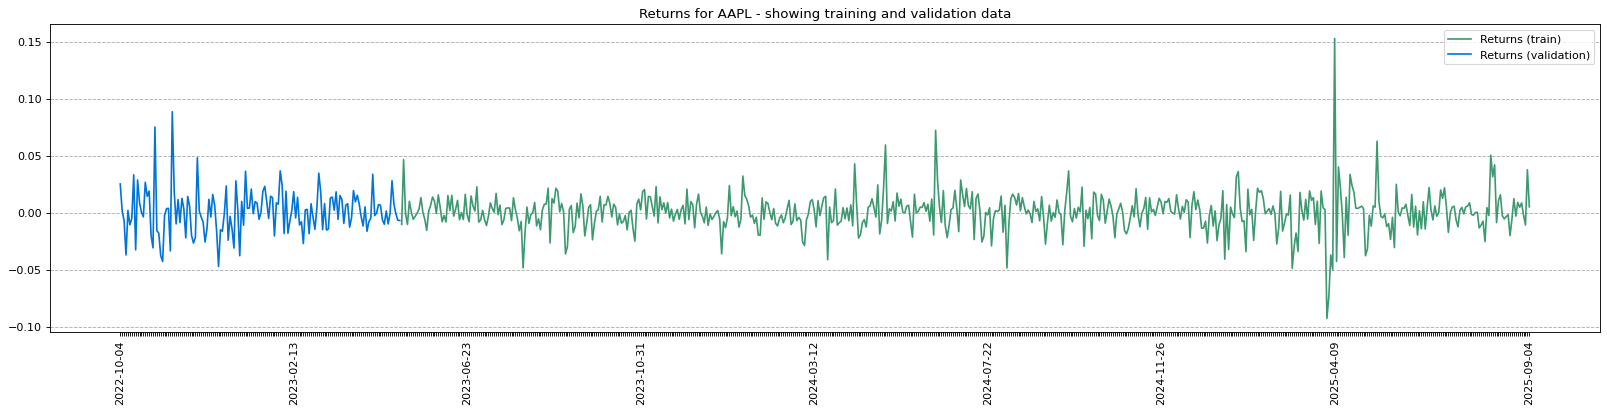

In [6]:
#@title Data Preparation: Generating Training and Validation Datasets

# prepare input x (features)
def prepare_data_x(x, vol, interest, window_size):
    # perform windowing for time series data
    # this will create a sliding window of size `window_size`
    n_row = x.shape[0] - window_size + 1
    x_output = np.lib.stride_tricks.as_strided(x, shape=(n_row,window_size), strides=(x.strides[0],x.strides[0]))
    vol_output = np.lib.stride_tricks.as_strided(vol, shape=(n_row,window_size), strides=(vol.strides[0],vol.strides[0]))
    interest_output = np.lib.stride_tricks.as_strided(interest, shape=(n_row,window_size), strides=(interest.strides[0],interest.strides[0]))
    combined_output = np.stack((x_output, vol_output, interest_output), axis=-1)
    return combined_output[:-1], combined_output[-1]

# prepare output y (target variable)
def prepare_data_y(y, window_size):
    # # perform simple moving average
    # output = np.convolve(x, np.ones(window_size), 'valid') / window_size

    # use the next day as label
    output = y[window_size:]
    return output

def prepare_data_y_binary(y, window_size):
    direction = 0.0 if y[window_size] < 0 else 1.0
    return direction

def prepare_data(data_date, normalized_data, normalized_vol, normalized_interest, config, plot=False):
    data_x, data_x_unseen = prepare_data_x(normalized_data, normalized_vol, normalized_interest, window_size=config["data"]["window_size"])
    data_y = prepare_data_y(normalized_data, window_size=config["data"]["window_size"])

    # split dataset: first 20% for validation, remaining 80% for training
    split_index = int(data_y.shape[0]*(1 - config["data"]["train_split_size"])) # Calculate index for first 20%
    # Split data with validation at the beginning and training at the end
    data_x_val = data_x[:split_index]
    data_x_train = data_x[split_index:]
    data_y_val = data_y[:split_index]
    data_y_train = data_y[split_index:]


    if plot:
        # prepare data for plotting
        # Remove the initial window_size entries from data_date, to_plot_data_y_train, and to_plot_data_y_val
        data_date_plot = data_date[config["data"]["window_size"]:]

        to_plot_data_y_train = np.full(len(data_y), np.nan)
        to_plot_data_y_val = np.full(len(data_y), np.nan)

        # Adjust slicing for plotting to match the new split
        to_plot_data_y_val[:split_index] = normalizer.inverse_transform(data_y_val)
        to_plot_data_y_train[split_index:] = normalizer.inverse_transform(data_y_train)

        # plots
        fig = figure(figsize=(25, 5), dpi=80)
        fig.patch.set_facecolor((1.0, 1.0, 1.0))
        # Adjust x-axis data to match the length of data_y
        plt.plot(data_date_plot, to_plot_data_y_train, label="Returns (train)", color=config["plots"]["color_train"])
        plt.plot(data_date_plot, to_plot_data_y_val, label="Returns (validation)", color=config["plots"]["color_val"])
        xticks = [data_date_plot[i] if ((i%config["plots"]["xticks_interval"]==0 and (len(data_date_plot)-i) > config["plots"]["xticks_interval"]) or i==len(data_date_plot)-1) else None for i in range(len(data_date_plot))]
        x = np.arange(0,len(xticks))
        plt.xticks(x, xticks, rotation='vertical')
        plt.title("Returns for " + config["yfinance"]["symbol"] + " - showing training and validation data")
        plt.grid(which='major', axis='y', linestyle='--')
        plt.legend()
        plt.show()

    return split_index, data_x_train, data_y_train, data_x_val, data_y_val, data_x_unseen

split_index, data_x_train, data_y_train, data_x_val, data_y_val, data_x_unseen = prepare_data(data_date, normalized_return, normalized_vol, normalized_interest, config, plot=config["plots"]["show_plots"])

In [7]:
#@title Instantiate Datasets

# create a dataset class for PyTorch
# this will allow us to use DataLoader for batching and shuffling
class TimeSeriesDataset(Dataset):
    def __init__(self, x, y):
        # Ensure x is in the shape [batch, sequence, features]
        # x is already [batch, sequence, features] from prepare_data_x, so no need to expand_dims
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)

    # return the length of the dataset
    def __len__(self):
        return len(self.x)

    # get item by index
    def __getitem__(self, idx):
        return (self.x[idx], self.y[idx])

# create training and validation datasets
dataset_train = TimeSeriesDataset(data_x_train, data_y_train)
dataset_val = TimeSeriesDataset(data_x_val, data_y_val)

# print the shapes (dimensions) of the datasets
print("Train data shape", dataset_train.x.shape, dataset_train.y.shape)
print("Validation data shape", dataset_val.x.shape, dataset_val.y.shape)

Train data shape (586, 20, 3) (586,)
Validation data shape (146, 20, 3) (146,)


In [8]:
#@title Defining the LSTM Model

class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_layer_size=32, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size # define hidden layer size

        self.linear_1 = nn.Linear(input_size, hidden_layer_size) # fully-connected layer to transform input size to hidden layer size
        self.relu = nn.ReLU() # ReLU activation function
        self.lstm = nn.LSTM(hidden_layer_size, hidden_size=self.hidden_layer_size, num_layers=num_layers, batch_first=True) # LSTM layer
        self.dropout = nn.Dropout(dropout) # dropout layer to prevent overfitting
        self.linear_2 = nn.Linear(num_layers*hidden_layer_size*2 if self.lstm.bidirectional else num_layers*hidden_layer_size, output_size) # linear layer to transform hidden layer size to output size

        self.init_weights() # initialize weights of the model

    def init_weights(self):
        for name, param in self.lstm.named_parameters():
            # initialize weights and biases
            # biases are initialized to 0
            if 'bias' in name:
                 nn.init.constant_(param, 0.0)
            # weights are initialized using Kaiming normal
            elif 'weight_ih' in name:
                 nn.init.kaiming_normal_(param)
            # weights for hidden-to-hidden connections are initialized using orthogonal initialization
            elif 'weight_hh' in name:
                 nn.init.orthogonal_(param)

    def forward(self, x):
        batchsize = x.shape[0]

        # layer 1
        x = self.linear_1(x)
        # activation function
        x = self.relu(x)

        # LSTM layer
        # long short-term memory (LSTM)
        _, (h_n, _) = self.lstm(x)

        # reshape output from hidden cell into [batch, features] for `linear_2`
        # If bidirectional, h_n shape is [num_layers * num_directions, batch, hidden_size]
        # We need to flatten the first two dimensions and then the last dimension
        x = h_n.permute(1, 0, 2).reshape(batchsize, -1)


        # layer 2
        x = self.dropout(x)
        logits = self.linear_2(x)
        return logits.squeeze(-1)

model = LSTMModel(input_size=config["model"]["input_size"], hidden_layer_size=config["model"]["lstm_size"], num_layers=config["model"]["num_lstm_layers"], output_size=1, dropout=config["model"]["dropout"])
model = model.to(device)

Epoch[1/100] | loss train:0.228677, test:0.070291 | lr:0.010000
Epoch[11/100] | loss train:0.171408, test:0.073150 | lr:0.010000
Epoch[21/100] | loss train:0.139336, test:0.077853 | lr:0.010000
Epoch[31/100] | loss train:0.098497, test:0.129394 | lr:0.010000
Epoch[41/100] | loss train:0.056646, test:0.094461 | lr:0.001000
Epoch[51/100] | loss train:0.042410, test:0.102650 | lr:0.001000
Epoch[61/100] | loss train:0.033625, test:0.117031 | lr:0.001000
Epoch[71/100] | loss train:0.030666, test:0.122924 | lr:0.001000
Epoch[81/100] | loss train:0.024394, test:0.125217 | lr:0.000100
Epoch[91/100] | loss train:0.021631, test:0.124216 | lr:0.000100


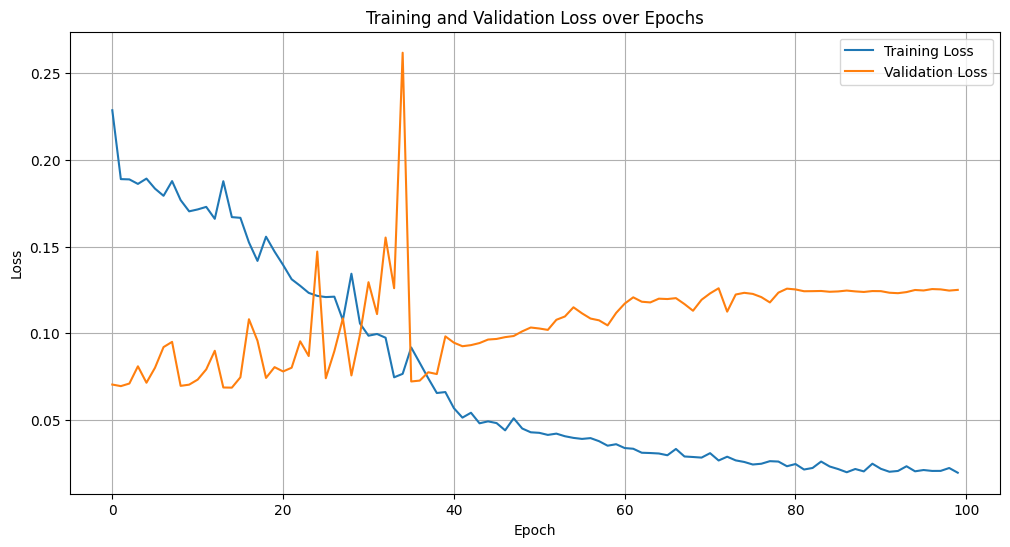

In [9]:
#@title Model Training

def run_epoch(dataloader, is_training=False):
    epoch_loss = 0

    if is_training:
        model.train()
    else:
        model.eval()

    for idx, (x, y) in enumerate(dataloader):
        if is_training:
            optimizer.zero_grad()

        batchsize = x.shape[0]

        x = x.to(device)
        y = y.to(device)

        out = model(x)
        loss = loss_function(out.contiguous(), y.contiguous())

        if is_training:
            loss.backward()
            optimizer.step()

        epoch_loss += (loss.detach().item() / batchsize)

    lr = scheduler.get_last_lr()[0]

    return epoch_loss, lr

# create `DataLoader`
train_dataloader = DataLoader(dataset_train, batch_size=config["training"]["batch_size"], shuffle=False)
val_dataloader = DataLoader(dataset_val, batch_size=config["training"]["batch_size"], shuffle=False)

# define optimizer, scheduler and loss function
loss_function = nn.MSELoss()
# update weights using Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=config["training"]["learning_rate"], betas=(0.9, 0.98), eps=1e-9)
# learning rate scheduler to reduce learning rate after a certain number of epochs
# this will help the model to improve convergence
# in this case, we will reduce the learning rate by a factor of 0.1
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=config["training"]["scheduler_step_size"], gamma=0.1)

# Store average training loss and validation accuracy
train_losses, val_losses = [], []

# begin training
for epoch in range(config["training"]["num_epoch"]):
    # run training and validation for one epoch
    loss_train, lr_train = run_epoch(train_dataloader, is_training=True)
    train_losses.append(loss_train) # Store training loss

    loss_val, lr_val = run_epoch(val_dataloader, is_training=False)
    val_losses.append(loss_val) # Store validation loss


    # update learning rate
    scheduler.step()

    if epoch % 10 == 0:
      print('Epoch[{}/{}] | loss train:{:.6f}, test:{:.6f} | lr:{:.6f}'
                .format(epoch+1, config["training"]["num_epoch"], loss_train, loss_val, lr_train))

# Plot the training and validation losses
plt.figure(figsize=(12, 6))
plt.plot(range(config["training"]["num_epoch"]), train_losses, label='Training Loss')
plt.plot(range(config["training"]["num_epoch"]), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Directional accuracy on validation set: 53.42%


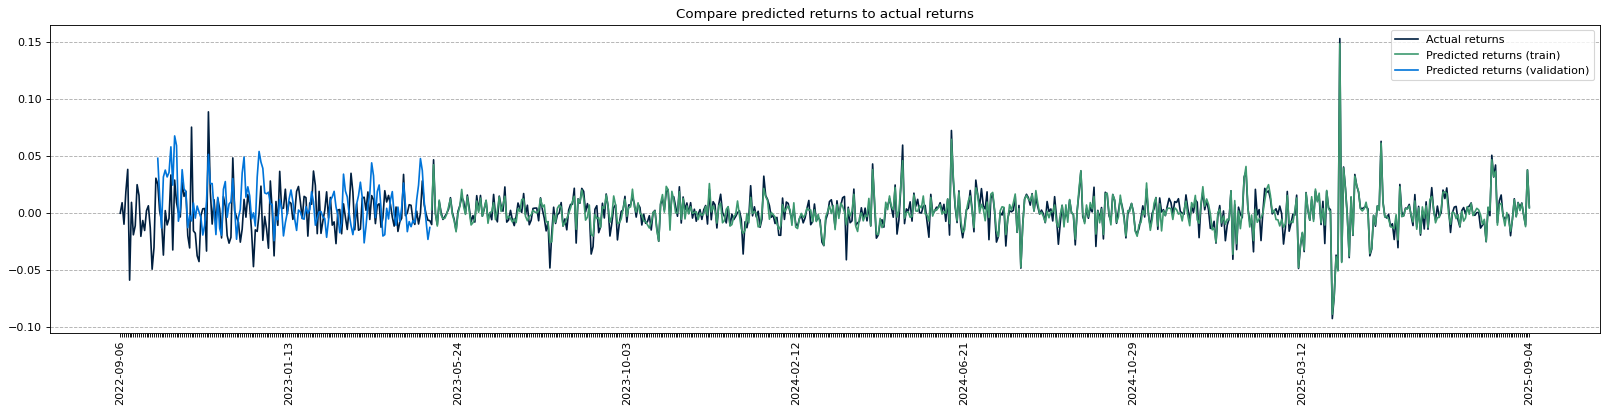

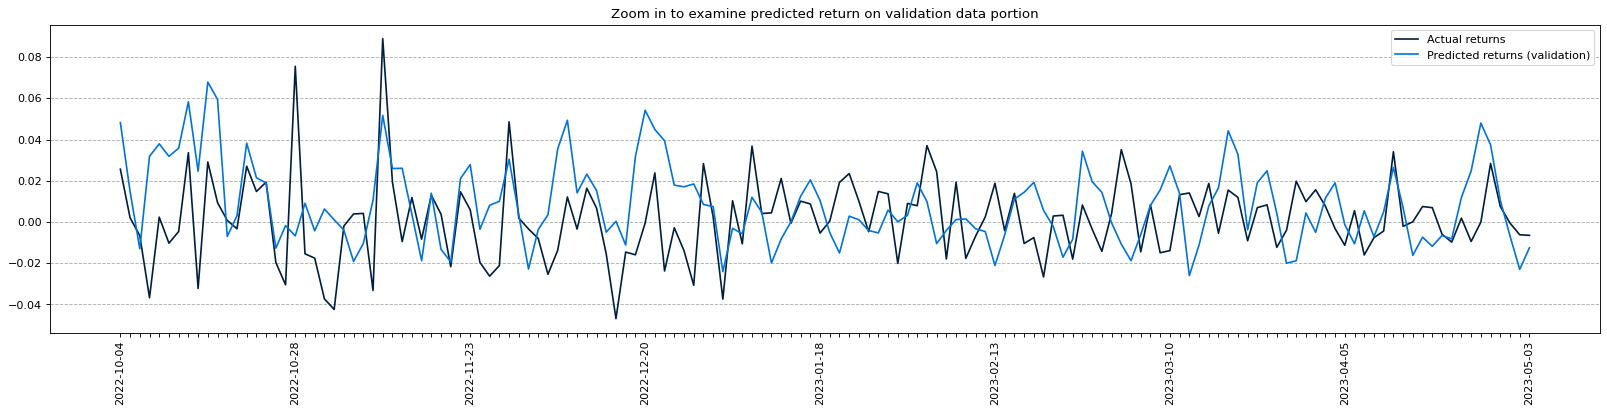

In [10]:
#@title Model Evaluation

# here we re-initialize dataloader so the data doesn't shuffle, so we can plot the values by date

train_dataloader = DataLoader(dataset_train, batch_size=config["training"]["batch_size"], shuffle=False)
val_dataloader = DataLoader(dataset_val, batch_size=config["training"]["batch_size"], shuffle=False)

model.eval()

# predict on the training data, to see how well the model managed to learn and memorize
predicted_train = np.array([])

# we will use the model to predict the training data
for idx, (x, y) in enumerate(train_dataloader):
    x = x.to(device)
    out = model(x)
    out = out.cpu().detach().numpy()
    predicted_train = np.concatenate((predicted_train, out))

# predict on the validation data, to see how the model does
predicted_val = np.array([])

for idx, (x, y) in enumerate(val_dataloader):
    x = x.to(device)
    out = model(x)
    out = out.cpu().detach().numpy()
    predicted_val = np.concatenate((predicted_val, out))

# Calculate directional accuracy on the validation set
actual_directions_val = np.sign(normalizer.inverse_transform(data_y_val))
predicted_directions_val = np.sign(normalizer.inverse_transform(predicted_val))

correct_direction_predictions = np.sum(actual_directions_val == predicted_directions_val)
total_predictions_val = len(actual_directions_val)
directional_accuracy = correct_direction_predictions / total_predictions_val * 100

print(f"Directional accuracy on validation set: {directional_accuracy:.2f}%")


if config["plots"]["show_plots"]:

    # prepare data for plotting, show predicted prices
    to_plot_data_y_train_pred = np.full(num_data_points, np.nan)
    to_plot_data_y_val_pred = np.full(num_data_points, np.nan)

    # Adjust slicing to match the new split: validation at the beginning, train at the end
    window_size = config["data"]["window_size"]
    to_plot_data_y_val_pred[window_size : split_index + window_size] = normalizer.inverse_transform(predicted_val)
    to_plot_data_y_train_pred[split_index + window_size : num_data_points] = normalizer.inverse_transform(predicted_train)

    # plots
    fig = figure(figsize=(25, 5), dpi=80)
    fig.patch.set_facecolor((1.0, 1.0, 1.0))
    plt.plot(data_date, data_return, label="Actual returns", color=config["plots"]["color_actual"])
    plt.plot(data_date, to_plot_data_y_train_pred, label="Predicted returns (train)", color=config["plots"]["color_pred_train"])
    plt.plot(data_date, to_plot_data_y_val_pred, label="Predicted returns (validation)", color=config["plots"]["color_pred_val"])
    plt.title("Compare predicted returns to actual returns")
    xticks = [data_date[i] if ((i%config["plots"]["xticks_interval"]==0 and (num_data_points-i) > config["plots"]["xticks_interval"]) or i==num_data_points-1) else None for i in range(num_data_points)] # make x ticks nice
    x = np.arange(0,len(xticks))
    plt.xticks(x, xticks, rotation='vertical')
    plt.grid(which='major', axis='y', linestyle='--')
    plt.legend()
    plt.show()

    # prepare data for plotting, zoom in validation
    # Adjust slicing to get the correct validation data subset
    to_plot_data_y_val_subset = normalizer.inverse_transform(data_y_val)
    to_plot_predicted_val = normalizer.inverse_transform(predicted_val)
    to_plot_data_date_val = data_date[window_size : split_index + window_size]


    # plots
    fig = figure(figsize=(25, 5), dpi=80)
    fig.patch.set_facecolor((1.0, 1.0, 1.0))
    plt.plot(to_plot_data_date_val, to_plot_data_y_val_subset, label="Actual returns", color=config["plots"]["color_actual"])
    plt.plot(to_plot_data_date_val, to_plot_predicted_val, label="Predicted returns (validation)", color=config["plots"]["color_pred_val"])
    plt.title("Zoom in to examine predicted return on validation data portion")
    xticks = [to_plot_data_date_val[i] if ((i%int(config["plots"]["xticks_interval"]/5)==0 and (len(to_plot_data_date_val)-i) > config["plots"]["xticks_interval"]/6) or i==len(to_plot_data_date_val)-1) else None for i in range(len(to_plot_data_date_val))] # make x ticks nice
    xs = np.arange(0,len(xticks))
    plt.xticks(xs, xticks, rotation='vertical')
    plt.grid(which='major', axis='y', linestyle='--')
    plt.legend()
    plt.show()

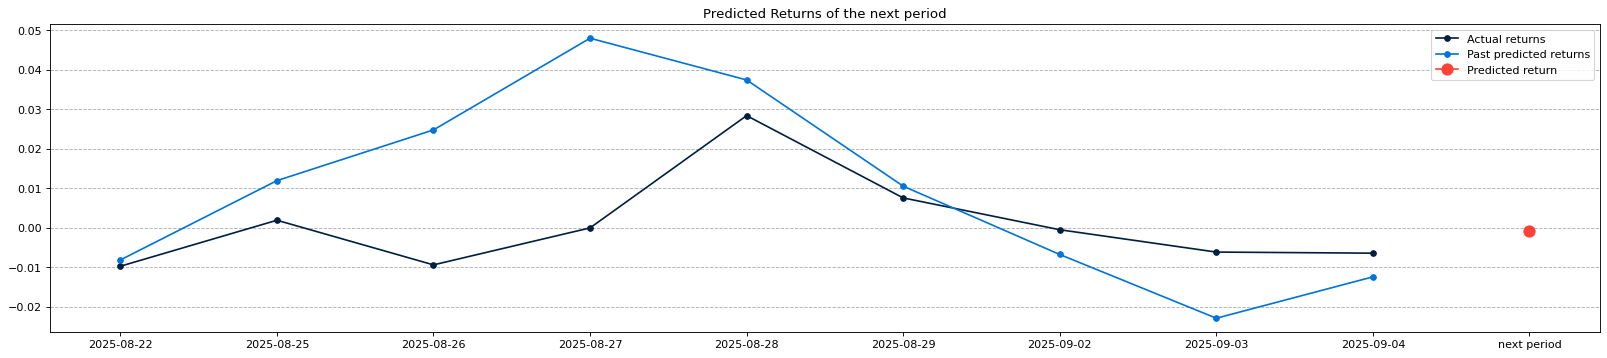

Predicted AAPL return of the next period: -0.0008


In [11]:
#@title Predicting Future Stock Prices

# predict on the unseen data (testing dataset), tomorrow's price
model.eval()

x = torch.tensor(data_x_unseen).float().to(device).unsqueeze(0) # this is the data type and shape required, [batch, sequence, feature]
prediction = model(x)
prediction = prediction.cpu().detach().numpy()
prediction = normalizer.inverse_transform(prediction)[0]

if config["plots"]["show_plots"]:

    # prepare plots
    plot_range = 10
    to_plot_data_y_val = np.zeros(plot_range)
    to_plot_data_y_val_pred = np.zeros(plot_range)
    to_plot_data_y_test_pred = np.zeros(plot_range)

    # Adjust slicing to get the last `plot_range - 1` values from the actual returns (data_return)
    # and the predicted returns (predicted_val)
    to_plot_data_y_val[:plot_range - 1] = normalizer.inverse_transform(data_y_val)[-(plot_range - 1):]
    to_plot_data_y_val_pred[:plot_range - 1] = normalizer.inverse_transform(predicted_val)[-(plot_range - 1):]

    to_plot_data_y_test_pred[plot_range-1] = prediction

    to_plot_data_y_val = np.where(to_plot_data_y_val == 0, None, to_plot_data_y_val)
    to_plot_data_y_val_pred = np.where(to_plot_data_y_val_pred == 0, None, to_plot_data_y_val_pred)
    to_plot_data_y_test_pred = np.where(to_plot_data_y_test_pred == 0, None, to_plot_data_y_test_pred)


    # plot
    # Adjust slicing for plot_date_test as well to match plot_range
    plot_date_test = data_date[-(plot_range-1):].copy()
    plot_date_test.append("next period")

    fig = figure(figsize=(25, 5), dpi=80)
    fig.patch.set_facecolor((1.0, 1.0, 1.0))
    plt.plot(plot_date_test, to_plot_data_y_val, label="Actual returns", marker=".", markersize=10, color=config["plots"]["color_actual"])
    plt.plot(plot_date_test, to_plot_data_y_val_pred, label="Past predicted returns", marker=".", markersize=10, color=config["plots"]["color_pred_val"])
    plt.plot(plot_date_test, to_plot_data_y_test_pred, label="Predicted return", marker=".", markersize=20, color=config["plots"]["color_pred_test"])
    plt.title("Predicted Returns of the next period")
    plt.grid(which='major', axis='y', linestyle='--')
    plt.legend()
    plt.show()

print(f"Predicted {config['yfinance']['symbol']} return of the next period:", round(prediction, 4))